In [85]:
import pandas as pd
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

data = pd.read_csv("2018_2025.csv", index_col="Name")

In [58]:
data_2023 = data[data["Season"] == 2023]
# grabbing the first N names
# N = 25
N = len(data_2023)
names = data_2023.index[0:N]
players = data_2023.iloc[0:N]
mu_global = data_2023["AVG"].mean()
K = data_2023["AB"]
K

Name
Ronald Acuna Jr.     643
Freddie Freeman      637
Mookie Betts         584
Shohei Ohtani        497
Matt Olson           608
                    ... 
Keibert Ruiz         523
Jose Abreu           540
Tyler Stephenson     465
Enrique Hernandez    465
Jurickson Profar     459
Name: AB, Length: 134, dtype: int64

In [59]:
players[["H", "AB", "AVG"]]
player_hits = players["H"]
player_averages = players["AVG"]
player_averages
K = players["AB"]

In [60]:
with pm.Model() as model_efron:
    mu = pm.Beta("mu", alpha=2, beta=8)
    kappa = pm.Gamma("kappa", alpha=1, beta=0.1)
    theta = pm.Beta("theta", mu * kappa, (1 - mu) * kappa, shape=len(player_averages))
    y = pm.Binomial("y", K, theta, observed=player_hits)
    idata = pm.sample(cores=8)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (8 chains in 8 jobs)
NUTS: [mu, kappa, theta]


Output()

Sampling 8 chains for 1_000 tune and 1_000 draw iterations (8_000 + 8_000 draws total) took 62 seconds.


In [84]:
# sampling priors
with model_efron:
    # Draw 1000 samples from the priors
    prior_samples = pm.sample_prior_predictive(samples=1000)

# Extract for plotting
mu_prior = prior_samples.prior["mu"].values.flatten()
kappa_prior = prior_samples.prior["kappa"].values.flatten()
theta_prior = prior_samples.prior["theta"].values.flatten()

Sampling: [kappa, mu, theta, y]


Text(0.5, 0, 'Kappa Value')

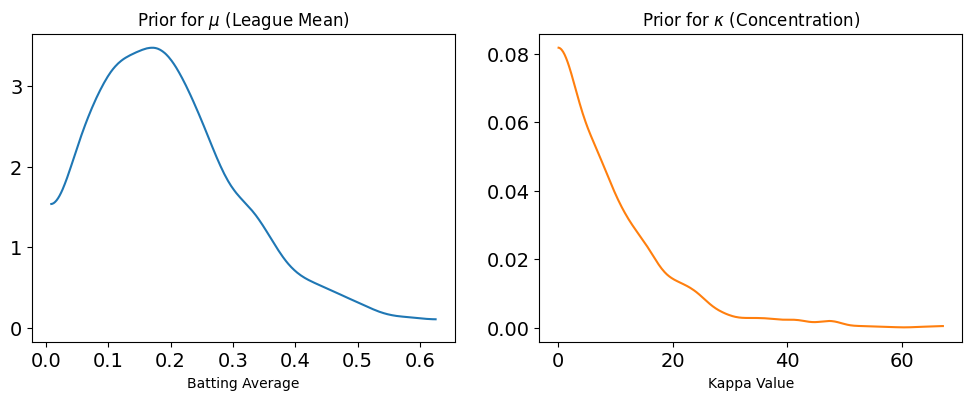

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Visualize mu: League-wide average
az.plot_dist(mu_prior, ax=axes[0], color="C0")
axes[0].set_title(r"Prior for $\mu$ (League Mean)")
axes[0].set_xlabel("Batting Average")

# Visualize kappa: Population concentration
az.plot_dist(kappa_prior, ax=axes[1], color="C1")
axes[1].set_title(r"Prior for $\kappa$ (Concentration)")
axes[1].set_xlabel("Kappa Value")

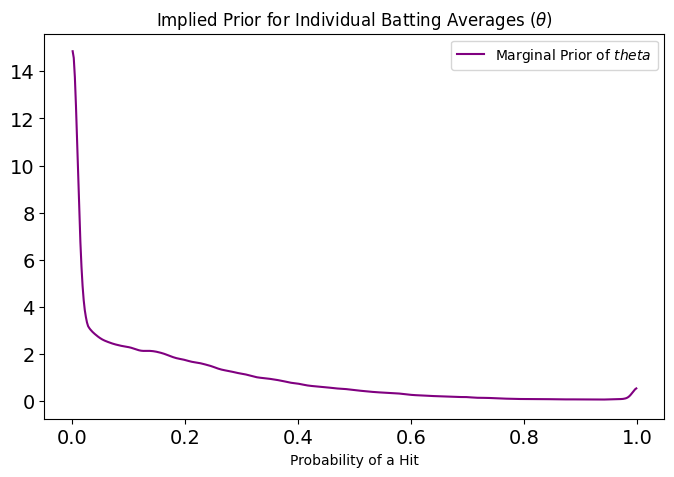

In [88]:
plt.figure(figsize=(8, 5))
# Plot the distribution of all sampled thetas
az.plot_dist(theta_prior, color="purple", label="Marginal Prior of $theta$")
plt.title(r"Implied Prior for Individual Batting Averages ($\theta$)")
plt.xlabel("Probability of a Hit")
plt.legend()

Text(0.5, 1.0, 'Prior Predictive Check: Simulated vs. Expected Hits')

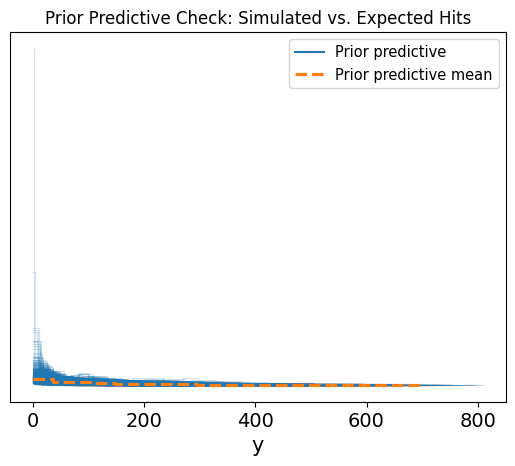

In [89]:
# Plots the distribution of simulated hits vs. your actual data structure
az.plot_ppc(prior_samples, group="prior", kind="kde")
plt.title("Prior Predictive Check: Simulated vs. Expected Hits")

In [61]:
import arviz as az
import matplotlib.pyplot as plt

# posterior means for each player's theta
post_means = az.summary(idata, var_names=["theta"])["mean"].values

# global league average (mu) mean
mu_mean = az.summary(idata, var_names=["mu"])["mean"].values[0]

# 3. Calculate observed averages from your original data
observed_avg = player_hits / K

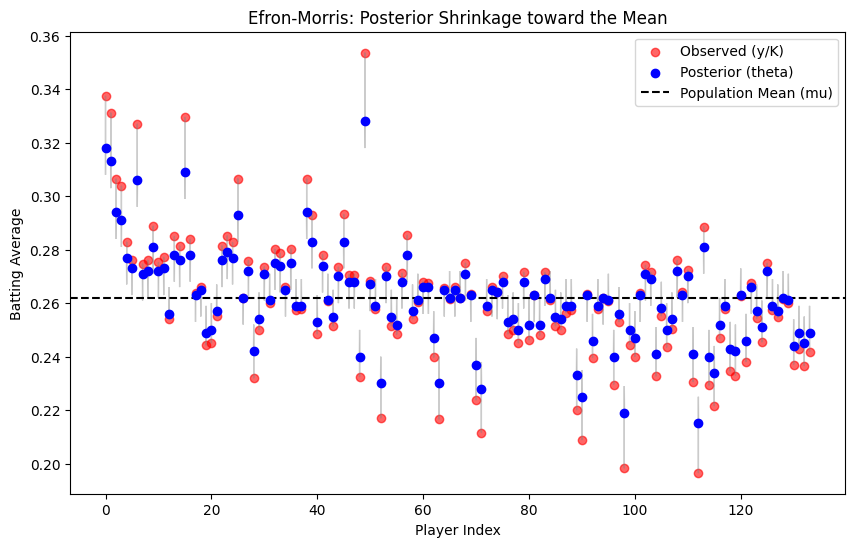

In [62]:
plt.figure(figsize=(10, 6))

# Plot observed data (Red) and posterior estimates (Blue)
plt.scatter(
    range(len(player_hits)),
    observed_avg,
    color="red",
    label="Observed (y/K)",
    alpha=0.6,
)
plt.scatter(
    range(len(player_hits)),
    post_means,
    color="blue",
    label="Posterior (theta)",
    zorder=3,
)

# Draw the global mean line
plt.axhline(mu_mean, color="black", linestyle="--", label="Population Mean (mu)")

# Draw arrows showing the "shrinkage"
for i in range(len(player_hits)):
    plt.arrow(
        i,
        observed_avg.iloc[i],
        0,
        post_means[i] - observed_avg.iloc[i],
        head_width=0.1,
        head_length=0.01,
        fc="gray",
        ec="gray",
        alpha=0.4,
    )

plt.title("Efron-Morris: Posterior Shrinkage toward the Mean")
plt.xlabel("Player Index")
plt.ylabel("Batting Average")
plt.legend()
plt.show()

Text(0.5, 1.0, '94% HDI for Individual Batting Averages')

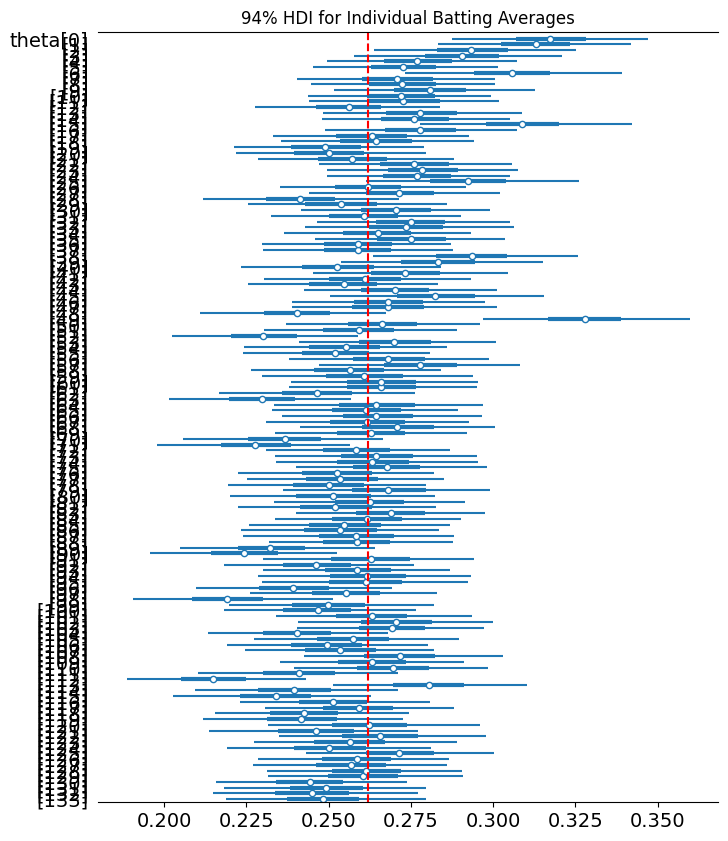

In [63]:
# This shows the uncertainty (HDI) for every player's batting average
az.plot_forest(
    idata,
    var_names=["theta"],
    combined=True,
    figsize=(8, 10),
)
plt.axvline(mu_mean, color="red", linestyle="--")  # Mark the global mean
plt.title("94% HDI for Individual Batting Averages")

In [64]:
with model_efron:
    # Generate 1000 simulated datasets (y_rep)
    ppc = pm.sample_posterior_predictive(idata, extend_inferencedata=True)

Sampling: [y]


Output()

<Axes: xlabel='y'>

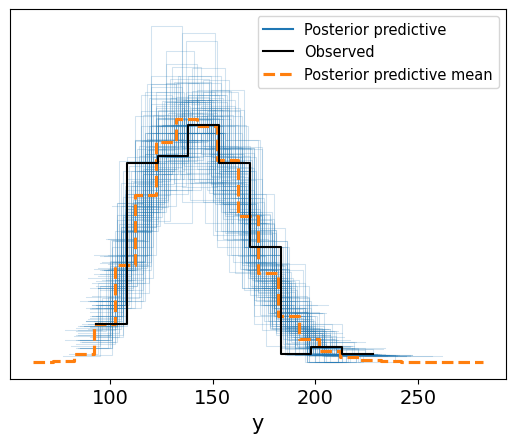

In [65]:
# Plot the distribution of observed vs simulated hits
az.plot_ppc(ppc, num_pp_samples=100)

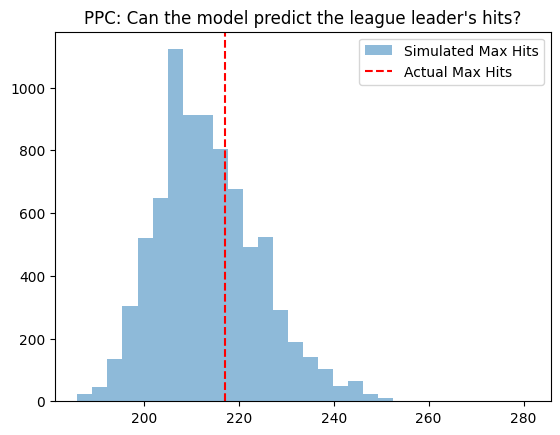

In [66]:
# Extract simulated hits from the ppc object
# Shape is (chain, draw, player_index)
y_sim = ppc.posterior_predictive["y"].values

# Calculate the maximum hits in each of the 1000 simulations
sim_max = y_sim.max(axis=2).flatten()

# Calculate the actual maximum hits in your real data
real_max = player_hits.max()

# Plot the comparison
plt.hist(sim_max, bins=30, alpha=0.5, label="Simulated Max Hits")
plt.axvline(real_max, color="red", linestyle="--", label="Actual Max Hits")
plt.legend()
plt.title("PPC: Can the model predict the league leader's hits?")
plt.show()

In [67]:
with pm.Model() as exponential_model:
    mu = pm.Beta("mu", alpha=2, beta=8)

    # Using Exponential instead of Gamma for more flexibility in concentration
    kappa = pm.Exponential("kappa", lam=0.1)

    theta = pm.Beta("theta", alpha=mu * kappa, beta=(1 - mu) * kappa, shape=N)
    y_obs = pm.Binomial("y_obs", n=K, p=theta, observed=player_hits)
    idata_e = pm.sample(cores=8)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (8 chains in 8 jobs)
NUTS: [mu, kappa, theta]


Output()

Sampling 8 chains for 1_000 tune and 1_000 draw iterations (8_000 + 8_000 draws total) took 67 seconds.


In [68]:
# posterior means for each player's theta
post_means = az.summary(idata_e, var_names=["theta"])["mean"].values

# global league average (mu) mean
mu_mean = az.summary(idata_e, var_names=["mu"])["mean"].values[0]

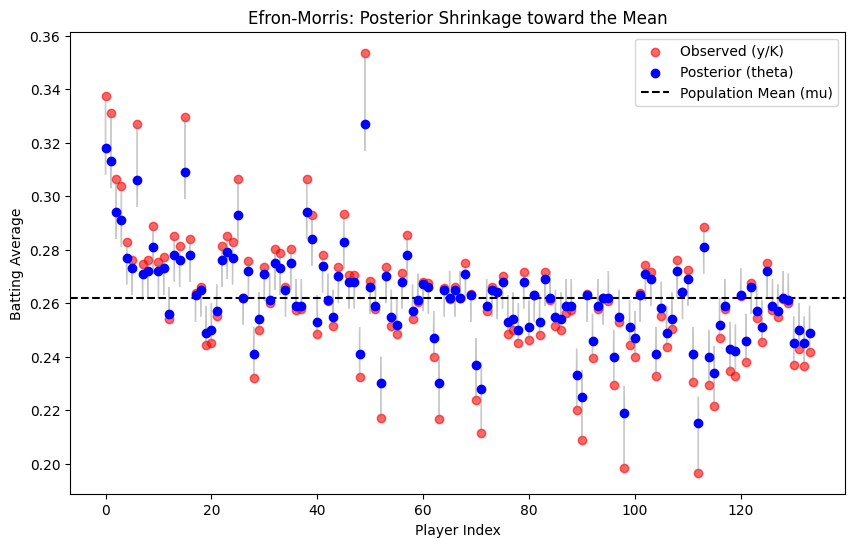

In [69]:
plt.figure(figsize=(10, 6))

# Plot observed data (Red) and posterior estimates (Blue)
plt.scatter(range(N), observed_avg, color="red", label="Observed (y/K)", alpha=0.6)
plt.scatter(range(N), post_means, color="blue", label="Posterior (theta)", zorder=3)

# Draw the global mean line
plt.axhline(mu_mean, color="black", linestyle="--", label="Population Mean (mu)")

# Draw arrows showing the "shrinkage"
for i in range(N):
    plt.arrow(
        i,
        observed_avg.iloc[i],
        0,
        post_means[i] - observed_avg.iloc[i],
        head_width=0.1,
        head_length=0.01,
        fc="gray",
        ec="gray",
        alpha=0.4,
    )

plt.title("Efron-Morris: Posterior Shrinkage toward the Mean")
plt.xlabel("Player Index")
plt.ylabel("Batting Average")
plt.legend()
plt.show()

Text(0.5, 1.0, '94% HDI for Individual Batting Averages')

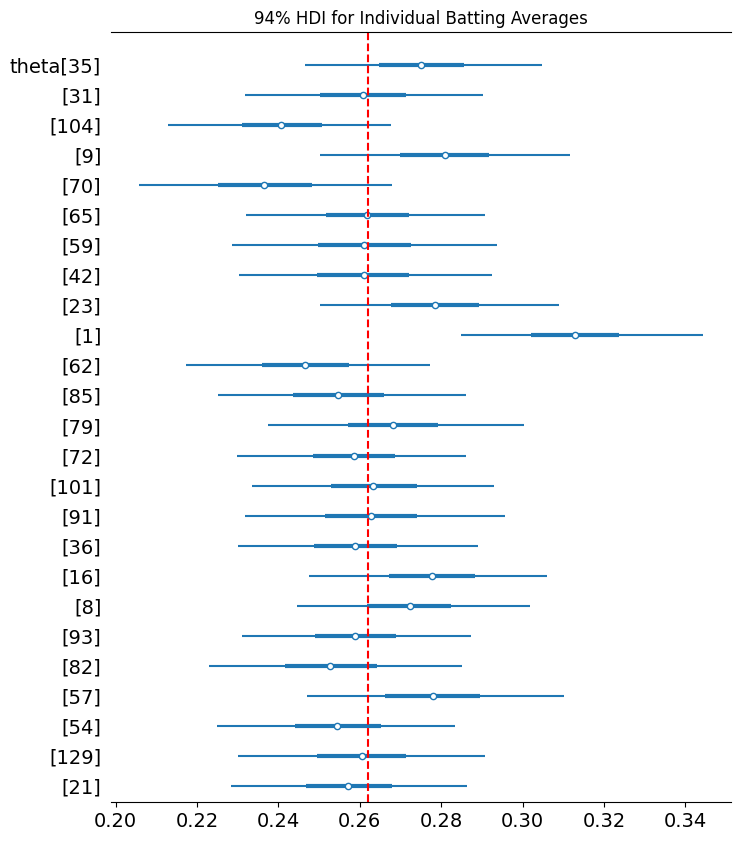

In [75]:
# picking n random players
num_to_plot = 25
random_indices = np.random.choice(range(N), size=num_to_plot, replace=False)
subset_idata = idata_e.posterior.isel(theta_dim_0=random_indices)
az.plot_forest(subset_idata, var_names=["theta"], combined=True, figsize=(8, 10))
plt.axvline(mu_mean, color="red", linestyle="--")  # Mark the global mean
plt.title("94% HDI for Individual Batting Averages")

In [76]:
with exponential_model:
    # Generate 1000 simulated datasets (y_rep)
    ppc = pm.sample_posterior_predictive(idata_e, extend_inferencedata=True)

Sampling: [y_obs]


Output()

<Axes: xlabel='y_obs'>

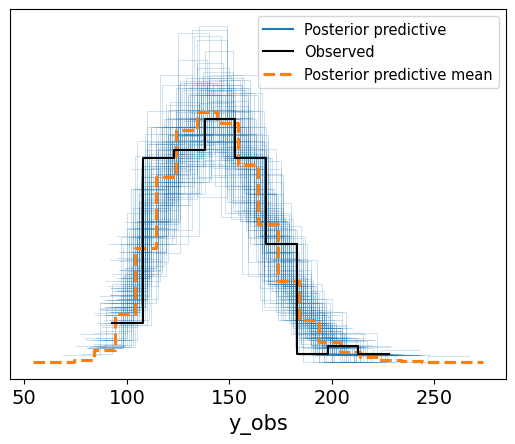

In [77]:
az.plot_ppc(ppc, num_pp_samples=100)

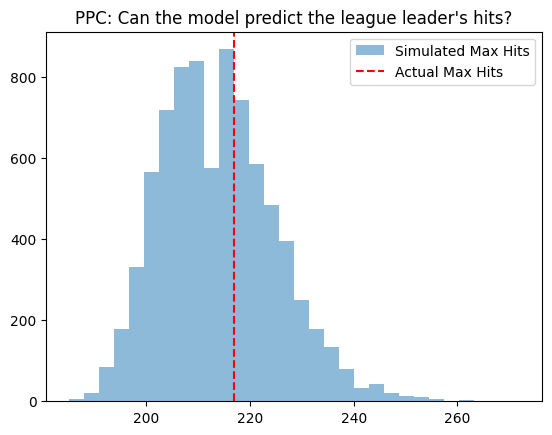

In [78]:
# Extract simulated hits from the ppc object
# Shape is (chain, draw, player_index)
y_sim = ppc.posterior_predictive["y_obs"].values

# Calculate the maximum hits in each of the 1000 simulations
sim_max = y_sim.max(axis=2).flatten()

# Calculate the actual maximum hits in your real data
real_max = player_hits.max()

# Plot the comparison
plt.hist(sim_max, bins=30, alpha=0.5, label="Simulated Max Hits")
plt.axvline(real_max, color="red", linestyle="--", label="Actual Max Hits")
plt.legend()
plt.title("PPC: Can the model predict the league leader's hits?")
plt.show()

In [79]:
# model on logit scale
import pytensor.tensor as pt

with pm.Model() as logit_normal_model:
    # --- Hyperpriors (on the Logit scale) ---
    # Intercept representing the league average (~.250 is -1.1 on logit scale)
    mu_league = pm.Normal("mu_league", mu=-1.1, sigma=0.5)

    # Population SD: How much players differ from each other
    # A smaller sigma means more shrinkage; larger means more "outliers" allowed
    sigma_league = pm.Exponential("sigma_league", 1.0)

    # --- Hierarchical Prior (Non-Centered Parameterization) ---
    # This trick helps PyMC sample much faster and avoids "divergences"
    z_offset = pm.Normal("z_offset", mu=0, sigma=1, shape=N)

    # Each player's ability on the logit scale
    logit_theta = pm.Deterministic("logit_theta", mu_league + z_offset * sigma_league)

    # Transform back to [0, 1] probability space
    theta = pm.Deterministic("theta", pm.math.invlogit(logit_theta))

    # --- Likelihood ---
    y_obs = pm.Binomial("y_obs", n=K, p=theta, observed=player_hits)

    # --- Inference ---
    trace = pm.sample(2000, tune=1000, cores=8)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (8 chains in 8 jobs)
NUTS: [mu_league, sigma_league, z_offset]


Output()

Sampling 8 chains for 1_000 tune and 2_000 draw iterations (8_000 + 16_000 draws total) took 78 seconds.


In [80]:
with logit_normal_model:
    ppc = pm.sample_posterior_predictive(trace, extend_inferencedata=True)

Sampling: [y_obs]


Output()

<Axes: xlabel='y_obs'>

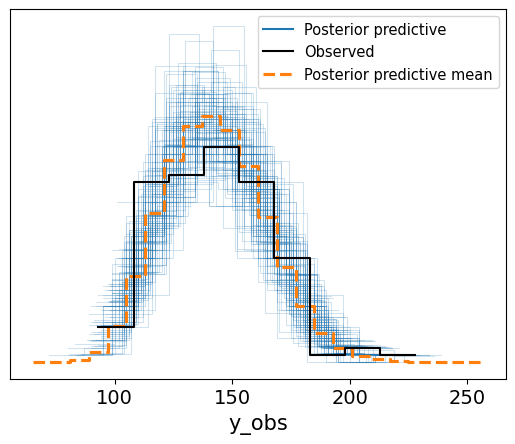

In [81]:
az.plot_ppc(ppc, num_pp_samples=100)

In [82]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_league,-1.037,0.012,-1.059,-1.016,0.000,0.000,10087.0,10160.0,1.0
z_offset[0],2.105,0.713,0.772,3.438,0.005,0.007,20691.0,10745.0,1.0
z_offset[1],1.933,0.708,0.558,3.232,0.005,0.006,20081.0,11707.0,1.0
z_offset[2],1.198,0.726,-0.215,2.507,0.005,0.006,19841.0,11333.0,1.0
z_offset[3],1.025,0.760,-0.389,2.469,0.005,0.007,20222.0,10640.0,1.0
...,...,...,...,...,...,...,...,...,...
theta[129],0.261,0.013,0.238,0.286,0.000,0.000,18854.0,11456.0,1.0
theta[130],0.251,0.013,0.228,0.275,0.000,0.000,18062.0,10881.0,1.0
theta[131],0.254,0.013,0.230,0.278,0.000,0.000,19603.0,11779.0,1.0
theta[132],0.252,0.013,0.227,0.276,0.000,0.000,18739.0,11811.0,1.0


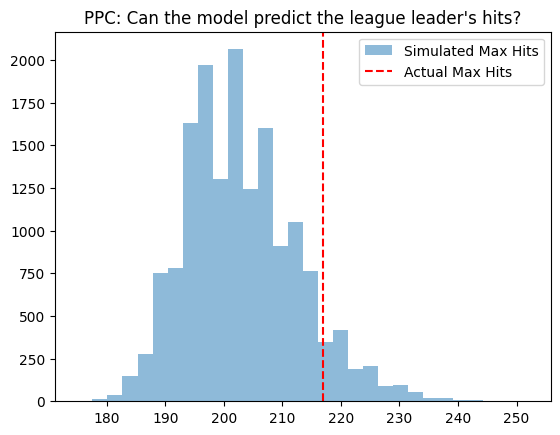

In [83]:
# Extract simulated hits from the ppc object
# Shape is (chain, draw, player_index)
y_sim = ppc.posterior_predictive["y_obs"].values

# Calculate the maximum hits in each of the 1000 simulations
sim_max = y_sim.max(axis=2).flatten()

# Calculate the actual maximum hits in your real data
real_max = player_hits.max()

# Plot the comparison
plt.hist(sim_max, bins=30, alpha=0.5, label="Simulated Max Hits")
plt.axvline(real_max, color="red", linestyle="--", label="Actual Max Hits")
plt.legend()
plt.title("PPC: Can the model predict the league leader's hits?")
plt.show()